# LASSO-Cox feature importance

Creates feature importance rankings for LASSO-Cox survival models (mRNA-only and Multi-omics).

On our data the multi-omics LASSO displayed great variation of selectet features (1-294) across folds. Picking one best fold would rest the whole ranking on this. So instead we run the whole 5-fold CV 5 times, each with a newly drawn stratified fold partition (5 seeds x 5 folds = 25 fits per model) and aggregate the importance and selection frequency of features. 

Per feature we report two scores:

1. **importance = mean |coef|** across all 25 fits.
2. **selection_frequency** = in what fraction of the 25 fits the feature was kept.

The alpha penalty is chosen with the 1-SE rule (form script 12).


## Imports & setup

In [19]:
import sys, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sksurv.util import Surv
from sksurv.linear_model import CoxnetSurvivalAnalysis
from sksurv.metrics import concordance_index_censored

sys.path.append("../scripts") 
from KNN_Imputation_Helper_Function import fit_transform_train_test_methylation

warnings.simplefilter("ignore") 
TABLES = Path("../results/tables"); TABLES.mkdir(parents=True, exist_ok=True)
FIGURES = Path("../results/figures"); FIGURES.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42        # inner-CV (alpha) seed
N_SEEDS = 5              # number of repeated outer CVs
SEEDS = list(range(N_SEEDS))

## Load and align data

Same four processed tables as the LASSO scripts, plus the CpG->gene map. All models share the same
patients. the outer folds are re-drawn per seed (see below).

In [20]:
rna   = pd.read_csv("../data/processed/rna_pam50.csv").set_index("patient")
meth  = pd.read_csv("../data/processed/meth_pam50.csv").set_index("patient")
surv  = pd.read_csv("../data/processed/survival_luminal_clean.csv").set_index("patient")
anno  = pd.read_csv("../data/processed/cpg_gene_map.csv")
cpg_to_gene = dict(zip(anno["cpg"], anno["gene"]))

surv = surv[surv["time"].notna() & (surv["time"] > 0)]
patients = rna.index.intersection(meth.index).intersection(surv.index)
rna, meth, surv = rna.loc[patients], meth.loc[patients], surv.loc[patients]
patients_arr = np.array(rna.index)

# Stratum for fresh outer partitions
stratum = (surv["BRCA_Subtype_PAM50"].astype(str) + "_" + surv["event"].astype(str))
strat_arr = stratum.loc[patients_arr].values
print(f"Patients: {len(patients)} | genes: {rna.shape[1]} | raw CpGs: {meth.shape[1]} "
      f"| events: {int(surv['event'].sum())} | strata: {sorted(set(strat_arr))}")

Patients: 556 | genes: 50 | raw CpGs: 572 | events: 65 | strata: ['LumA_0', 'LumA_1', 'LumB_0', 'LumB_1']


### Helpfer functions

Reproduce the exact preprocessing of scripts 11/12 so the importances match the models. 

In [25]:
def survival_y(ids):
    return Surv.from_arrays(event=surv.loc[ids, "event"].astype(bool).values,
                            time=surv.loc[ids, "time"].values)


def beta_to_m(B):
    """Beta (0-1) -> M-value = log2(beta / (1 - beta)); clipped so the log stays finite."""
    B = B.clip(1e-4, 1 - 1e-4)
    return np.log2(B / (1 - B))


def build_features_mrna(train_ids, test_ids):
    scaler = StandardScaler().fit(rna.loc[train_ids])
    X_tr = scaler.transform(rna.loc[train_ids])
    X_te = scaler.transform(rna.loc[test_ids])
    feature_names = [f"RNA: {g}" for g in rna.columns]
    return X_tr, X_te, feature_names


def build_features_multi(train_ids, test_ids):
    Bm_tr, Bm_te, _ = fit_transform_train_test_methylation(meth, train_ids, test_ids, scale=False)
    Mm_tr, Mm_te = beta_to_m(Bm_tr), beta_to_m(Bm_te)
    m_scaler = StandardScaler().fit(Mm_tr)
    Mm_tr = pd.DataFrame(m_scaler.transform(Mm_tr), index=Mm_tr.index, columns=Mm_tr.columns)
    Mm_te = pd.DataFrame(m_scaler.transform(Mm_te), index=Mm_te.index, columns=Mm_te.columns)

    r_scaler = StandardScaler().fit(rna.loc[train_ids])
    Xr_tr = pd.DataFrame(r_scaler.transform(rna.loc[train_ids]), index=train_ids, columns=rna.columns)
    Xr_te = pd.DataFrame(r_scaler.transform(rna.loc[test_ids]),  index=test_ids,  columns=rna.columns)

    X_tr = pd.concat([Xr_tr, Mm_tr], axis=1).to_numpy()
    X_te = pd.concat([Xr_te, Mm_te], axis=1).to_numpy()
    feature_names = ([f"RNA: {g}" for g in rna.columns] +
                     [f"METH: {cpg_to_gene.get(c, 'Unknown')} ({c})" for c in Mm_tr.columns])
    return X_tr, X_te, feature_names


def select_alpha(X, y, alphas):
    """1-SE rule (unchanged from script 12): sparsest alpha within 1 SE of the best mean C-index."""
    inner = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
    scores = np.full((inner.get_n_splits(), len(alphas)), np.nan)
    for k, (i_tr, i_va) in enumerate(inner.split(X, y["event"])):
        model = CoxnetSurvivalAnalysis(l1_ratio=1.0, alphas=alphas, max_iter=100000)
        try:
            model.fit(X[i_tr], y[i_tr])
            for j, a in enumerate(alphas):
                risk = model.predict(X[i_va], alpha=a)
                scores[k, j] = concordance_index_censored(
                    y[i_va]["event"], y[i_va]["time"], risk)[0]
        except (ArithmeticError, ValueError):
            continue
    mean = np.nanmean(scores, axis=0)
    se = np.nanstd(scores, axis=0, ddof=1) / np.sqrt(np.sum(~np.isnan(scores), axis=0))
    best = np.nanargmax(mean)
    candidates = np.where(mean >= mean[best] - se[best])[0]
    return alphas[candidates[0]]


def fit_final_with_fallback(X_tr, y_tr, selected_alpha, alphas):
    for a in np.sort(alphas)[np.sort(alphas) >= selected_alpha]:
        try:
            m = CoxnetSurvivalAnalysis(l1_ratio=1.0, alphas=[a], max_iter=100000)
            m.fit(X_tr, y_tr)
            return m, a
        except ArithmeticError:
            continue
    raise RuntimeError("No alpha converged; raise alpha_min_ratio.")

### Repeated-CV LASSO importance


In [ ]:
def repeated_lasso_importance(build_features, alpha_min_ratio):
    sum_abs, sel_count, n_runs, counts = {}, {}, 0, []
    for seed in SEEDS:
        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)
        for fold, (tr_idx, te_idx) in enumerate(skf.split(patients_arr, strat_arr)):
            train_ids = pd.Index(patients_arr[tr_idx])
            test_ids  = pd.Index(patients_arr[te_idx])
            X_tr, X_te, names = build_features(train_ids, test_ids)
            y_tr = survival_y(train_ids)

            alphas = CoxnetSurvivalAnalysis(l1_ratio=1.0, n_alphas=100,
                                            alpha_min_ratio=alpha_min_ratio,
                                            max_iter=100000).fit(X_tr, y_tr).alphas_
            best_alpha = select_alpha(X_tr, y_tr, alphas)
            final, _ = fit_final_with_fallback(X_tr, y_tr, best_alpha, alphas)
            coef = np.abs(final.coef_.ravel())

            n_runs += 1
            
            counts.append({"seed": seed, "fold": fold,
                           "n_selected": int((coef != 0).sum()),
                           "n_features_total": len(names)})
            for name, c in zip(names, coef):
                sum_abs[name] = sum_abs.get(name, 0.0) + c
                sel_count[name] = sel_count.get(name, 0) + (1 if c != 0 else 0)
        print(f"  seed {seed}: done ({n_runs} fits so far)")
    return sum_abs, sel_count, n_runs, counts


def to_importance_table(sum_abs, sel_count, n_runs, model_name):
    """Tidy per-feature table, schema shared across all four models."""
    rows = []
    for name in sum_abs:
        modality = "METH" if name.startswith("METH") else "RNA"
        if modality == "RNA":
            gene, cpg = name.split("RNA: ")[1], np.nan
        else:
            inner = name.split("METH: ")[1]         
            gene, cpg = inner.split(" (")[0], inner.split("(")[1].rstrip(")")
        rows.append({"model": model_name, "feature": name, "modality": modality,
                     "gene": gene, "cpg": cpg,
                     "importance": sum_abs[name] / n_runs,
                     "selection_frequency": sel_count[name] / n_runs})
    df = pd.DataFrame(rows).sort_values("importance", ascending=False).reset_index(drop=True)
    df["rank"] = np.arange(1, len(df) + 1)
    return df

### mRNA-only LASSO-Cox

In [26]:
sa, sc, nr, cnt_mrna = repeated_lasso_importance(build_features_mrna, alpha_min_ratio=0.01)
imp_mrna = to_importance_table(sa, sc, nr, "LASSO_mRNA")
imp_mrna.to_csv(TABLES / "feature_importance_lasso_mrna.csv", index=False)
print(f"mRNA LASSO aggregated over {nr} fits")
imp_mrna.head(10)

  seed 0: done (5 fits so far)
  seed 1: done (10 fits so far)
  seed 2: done (15 fits so far)
  seed 3: done (20 fits so far)
  seed 4: done (25 fits so far)
mRNA LASSO aggregated over 25 fits


,model,feature,modality,gene,cpg,importance,selection_frequency,rank
0,LASSO_mRNA,RNA: BLVRA,RNA,BLVRA,NaN,0.157851,0.84,1
1,LASSO_mRNA,RNA: EXO1,RNA,EXO1,NaN,0.122502,0.16,2
2,LASSO_mRNA,RNA: NDC80,RNA,NDC80,NaN,0.119021,0.20,3
3,LASSO_mRNA,RNA: MMP11,RNA,MMP11,NaN,0.097659,0.68,4
4,LASSO_mRNA,RNA: KRT5,RNA,KRT5,NaN,0.095237,0.44,5
5,LASSO_mRNA,RNA: MELK,RNA,MELK,NaN,0.094259,0.16,6
6,LASSO_mRNA,RNA: PTTG1,RNA,PTTG1,NaN,0.087902,0.16,7
7,LASSO_mRNA,RNA: KIF2C,RNA,KIF2C,NaN,0.085688,0.20,8
8,LASSO_mRNA,RNA: MAPT,RNA,MAPT,NaN,0.078639,0.40,9
9,LASSO_mRNA,RNA: NUF2,RNA,NUF2,NaN,0.075833,0.16,10


### Multi-omics LASSO-Cox

In [22]:
sa, sc, nr, cnt_multi = repeated_lasso_importance(build_features_multi, alpha_min_ratio=0.05)
imp_multi = to_importance_table(sa, sc, nr, "LASSO_multiomics")
imp_multi.to_csv(TABLES / "feature_importance_lasso_multiomics.csv", index=False)
print(f"Multi-omics LASSO aggregated over {nr} fits | "
      f"features ever selected: {(imp_multi['selection_frequency'] > 0).sum()}")
imp_multi.head(10)

  seed 0: done (5 fits so far)
  seed 1: done (10 fits so far)
  seed 2: done (15 fits so far)
  seed 3: done (20 fits so far)
  seed 4: done (25 fits so far)
Multi-omics LASSO aggregated over 25 fits | features ever selected: 177


,model,feature,modality,gene,cpg,importance,selection_frequency,rank
0,LASSO_multiomics,RNA: BLVRA,RNA,BLVRA,NaN,0.148496,0.92,1
1,LASSO_multiomics,METH: ESR1 (cg00920970),METH,ESR1,cg00920970,0.108884,0.76,2
2,LASSO_multiomics,METH: EXO1 (cg12401425),METH,EXO1,cg12401425,0.074564,0.52,3
3,LASSO_multiomics,RNA: MMP11,RNA,MMP11,NaN,0.067515,0.68,4
4,LASSO_multiomics,METH: MLPH (cg05240479),METH,MLPH,cg05240479,0.065278,0.36,5
5,LASSO_multiomics,METH: CDC20 (cg00615260),METH,CDC20,cg00615260,0.059075,0.40,6
6,LASSO_multiomics,METH: SFRP1 (cg17816908),METH,SFRP1,cg17816908,0.054582,0.24,7
7,LASSO_multiomics,METH: ESR1 (cg07619683),METH,ESR1,cg07619683,0.053034,0.40,8
8,LASSO_multiomics,METH: BAG1 (cg01177235),METH,BAG1,cg01177235,0.052594,0.44,9
9,LASSO_multiomics,METH: ESR1 (cg21157690),METH,ESR1,cg21157690,0.050564,0.56,10


### How many features did each single fit keep?

Because we observed models selecting 0 to 294 features, we want to check visually how many features are kept in each fit.

                  min  median  mean  max   std
model                                         
LASSO_mRNA          0     3.0   8.9   43  12.6
LASSO_multiomics    0    12.0  22.0   77  23.4


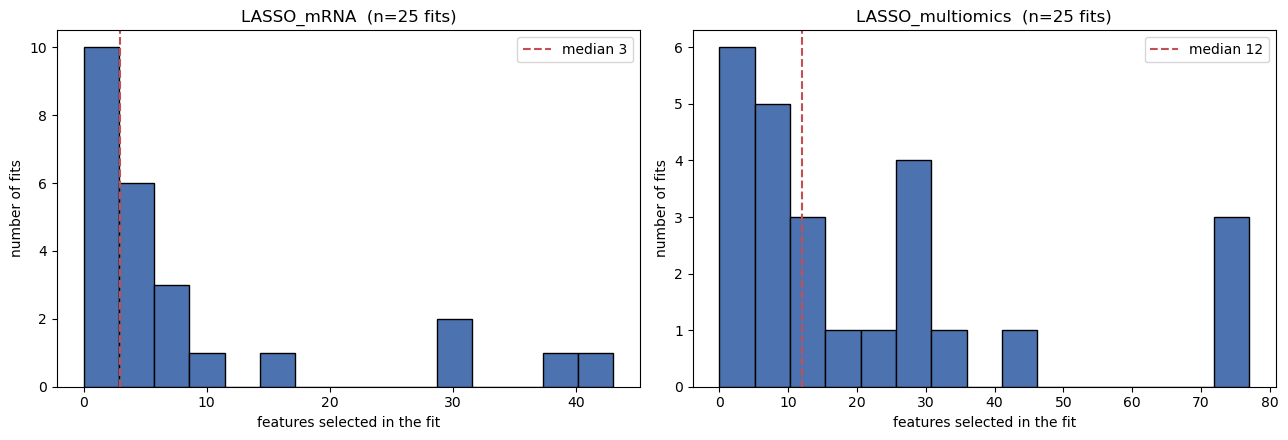

In [18]:
cnt = pd.concat([
    pd.DataFrame(cnt_mrna).assign(model="LASSO_mRNA"),
    pd.DataFrame(cnt_multi).assign(model="LASSO_multiomics")], ignore_index=True)
cnt.to_csv(TABLES / "lasso_selection_count_per_run.csv", index=False)

summary = cnt.groupby("model")["n_selected"].agg(["min", "median", "mean", "max", "std"]).round(1)
print(summary.to_string())

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for ax, model in zip(axes, ["LASSO_mRNA", "LASSO_multiomics"]):
    d = cnt[cnt.model == model]
    ax.hist(d["n_selected"], bins=15, color="#4C72B0", edgecolor="black")
    ax.axvline(d["n_selected"].median(), color="#C44E52", ls="--",
               label=f"median {int(d['n_selected'].median())}")
    ax.set_title(f"{model}  (n={len(d)} fits)")
    ax.set_xlabel("features selected in the fit"); ax.set_ylabel("number of fits")
    ax.legend()
plt.tight_layout()
plt.savefig(FIGURES / "lasso_selection_count_per_run.png", dpi=300)
plt.show()

### Gene-level view of the multi-omics model

Collapse CpGs to genes for acompact summary. Rank is only based on importancenot selection freq. 


In [23]:
non_zero = imp_multi[imp_multi["importance"] > 0].copy()
gene_level = (non_zero.groupby("gene")
              .agg(importance=("importance", "max"),
                   selection_frequency=("selection_frequency", "max"),
                   modalities=("modality", lambda s: "+".join(sorted(set(s)))),
                   n_features=("feature", "size"))
              .sort_values("importance", ascending=False).reset_index())
gene_level["rank"] = np.arange(1, len(gene_level) + 1)
gene_level.to_csv(TABLES / "feature_importance_lasso_multiomics_gene_level.csv", index=False)
gene_level.head(15)

,gene,importance,selection_frequency,modalities,n_features,rank
0,BLVRA,0.148496,0.92,METH+RNA,4,1
1,ESR1,0.108884,0.76,METH,14,2
2,EXO1,0.074564,0.52,METH,6,3
3,MMP11,0.067515,0.68,METH+RNA,5,4
4,MLPH,0.065278,0.48,METH+RNA,4,5
5,CDC20,0.059075,0.40,METH+RNA,6,6
6,SFRP1,0.054582,0.28,METH,7,7
7,BAG1,0.052594,0.44,METH+RNA,4,8
8,CCNB1,0.050250,0.48,METH,3,9
9,ERBB2,0.047831,0.32,METH+RNA,4,10


## Visualisation — top features by importance and by selection frequency


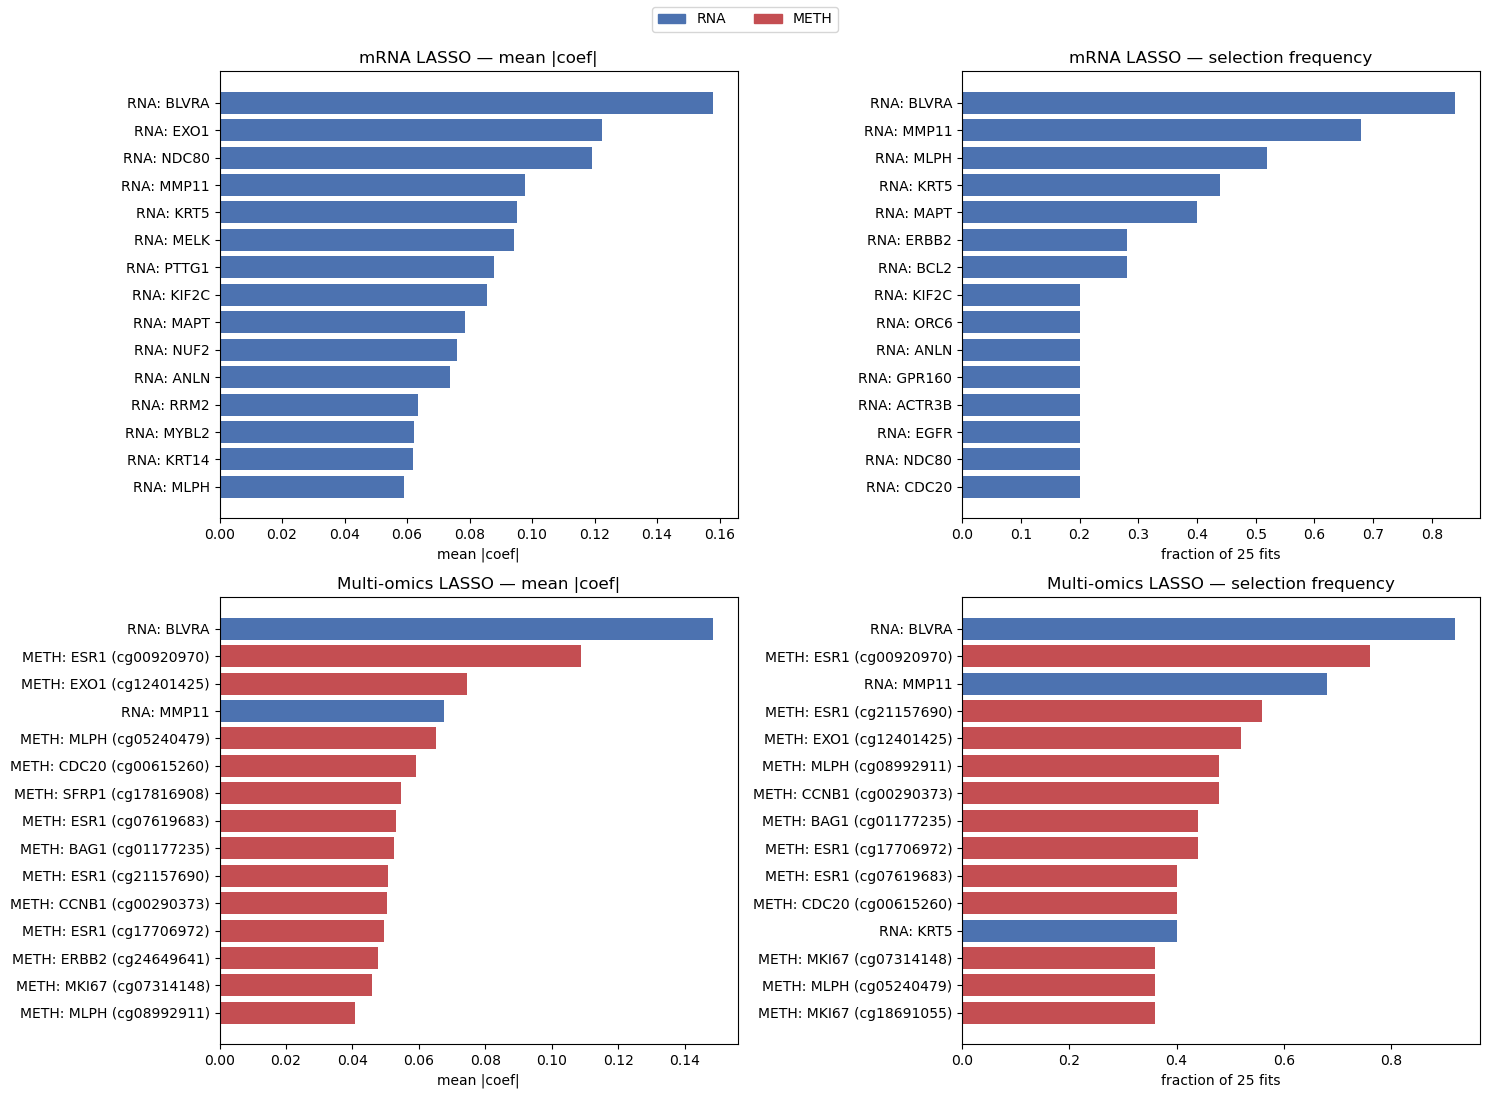

In [24]:
fig, axes = plt.subplots(2, 2, figsize=(15, 11))

def barh(ax, df, col, title, xlabel):
    d = df.sort_values(col, ascending=False).head(15).iloc[::-1]
    colors = ["#4C72B0" if m == "RNA" else "#C44E52" for m in d["modality"]]
    ax.barh(d["feature"], d[col], color=colors)
    ax.set_xlabel(xlabel); ax.set_title(title)

barh(axes[0, 0], imp_mrna[imp_mrna.importance > 0], "importance",
     "mRNA LASSO — mean |coef|", "mean |coef|")
barh(axes[0, 1], imp_mrna[imp_mrna.importance > 0], "selection_frequency",
     "mRNA LASSO — selection frequency", "fraction of 25 fits")
barh(axes[1, 0], imp_multi[imp_multi.importance > 0], "importance",
     "Multi-omics LASSO — mean |coef|", "mean |coef|")
barh(axes[1, 1], imp_multi[imp_multi.importance > 0], "selection_frequency",
     "Multi-omics LASSO — selection frequency", "fraction of 25 fits")

handles = [plt.Rectangle((0, 0), 1, 1, color=c) for c in ("#4C72B0", "#C44E52")]
fig.legend(handles, ["RNA", "METH"], loc="upper center", ncol=2)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.savefig(FIGURES / "lasso_feature_importance_repeatedcv.png", dpi=300)
plt.show()

## Summary

Outputs:

- `feature_importance_lasso_mrna.csv`
- `feature_importance_lasso_multiomics.csv`
- `feature_importance_lasso_multiomics_gene_level.csv`
- `lasso_selection_count_per_run.png`
- `lasso_feature_importance_repeatedcv.png`
